In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
train_dataset = datasets.ImageFolder("car_data/train", transform=train_transforms)
test_dataset = datasets.ImageFolder("car_data/test", transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset.classes
print("Classes:", classes)

Classes: ['Hatchback', 'Other', 'Pickup', 'SUV', 'Sedan']


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 56 * 56, 128),  # 224 -> 112 -> 56
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

baseline_model = SimpleCNN(len(classes)).to(device)

In [6]:
resnet_model = models.resnet18(pretrained=True)

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, len(classes))

resnet_model = resnet_model.to(device)
print("ResNet ready")

ResNet ready


c:\Users\youss\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\youss\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
def train_model(model, train_loader, epochs=5, lr=0.001):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")
    
    return losses

In [8]:
print("Training Baseline...")
baseline_losses = train_model(baseline_model, train_loader, epochs=5, lr=0.001)

print("\nTraining ResNet...")
resnet_losses = train_model(resnet_model, train_loader, epochs=8, lr=0.0005)

Training Baseline...
Epoch [1/5], Loss: 1.2260
Epoch [2/5], Loss: 0.4777
Epoch [3/5], Loss: 0.2743
Epoch [4/5], Loss: 0.1687
Epoch [5/5], Loss: 0.1283

Training ResNet...
Epoch [1/8], Loss: 0.3533
Epoch [2/8], Loss: 0.0906
Epoch [3/8], Loss: 0.1062
Epoch [4/8], Loss: 0.0438
Epoch [5/8], Loss: 0.0329
Epoch [6/8], Loss: 0.0385
Epoch [7/8], Loss: 0.0513
Epoch [8/8], Loss: 0.0480


In [9]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    return accuracy, all_labels, all_preds

In [10]:
baseline_acc, _, _ = evaluate_model(baseline_model, test_loader)
resnet_acc, all_labels, all_preds = evaluate_model(resnet_model, test_loader)

print("Baseline Accuracy:", baseline_acc)
print("ResNet Accuracy:", resnet_acc)

Baseline Accuracy: 95.625
ResNet Accuracy: 98.61111111111111


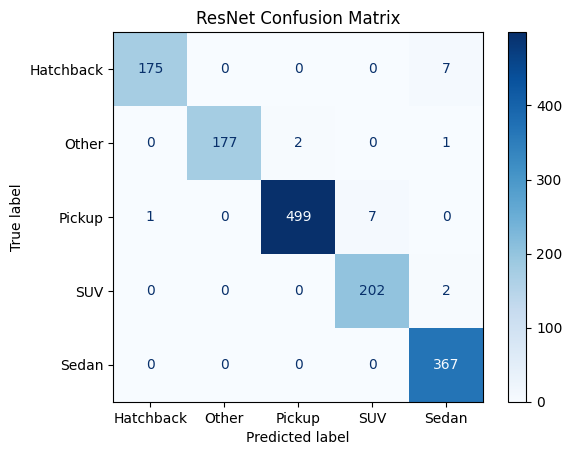

In [11]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues")
plt.title("ResNet Confusion Matrix")
plt.show()

In [12]:
def predict_car_type(img_path):
    
    image = Image.open(img_path).convert("RGB")
    input_tensor = test_transforms(image).unsqueeze(0).to(device)
    
    resnet_model.eval()
    
    with torch.no_grad():
        output = resnet_model(input_tensor)
        _, predicted_idx = torch.max(output, 1)
    
    car_type = classes[predicted_idx.item()]
    
    plt.imshow(image)
    plt.title(f"I think this is a: {car_type}")
    plt.axis("off")
    plt.show()

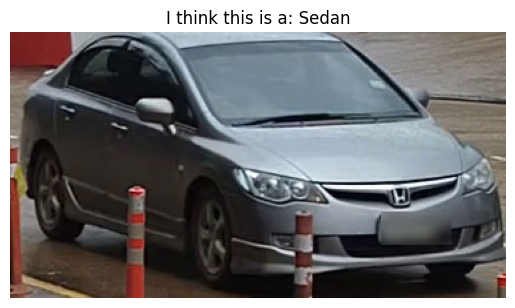

In [16]:
predict_car_type("Test_image.jpg")

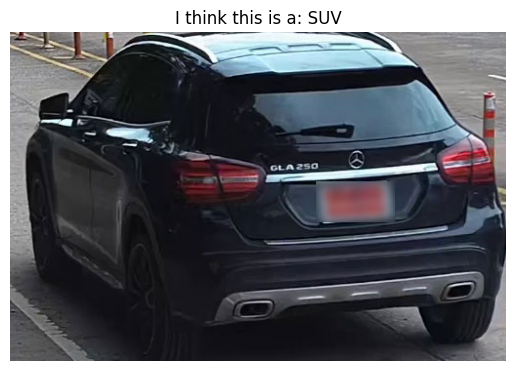

In [17]:
predict_car_type("Test_image1.jpg")

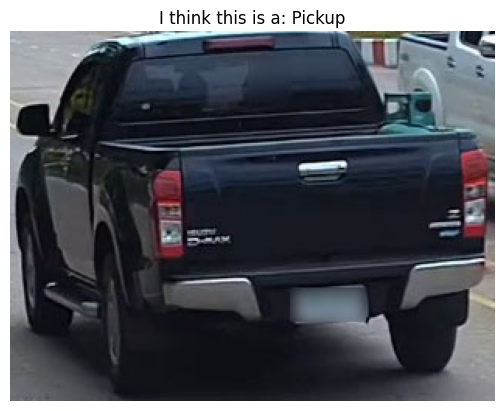

In [18]:
predict_car_type("Test_image2.jpg")

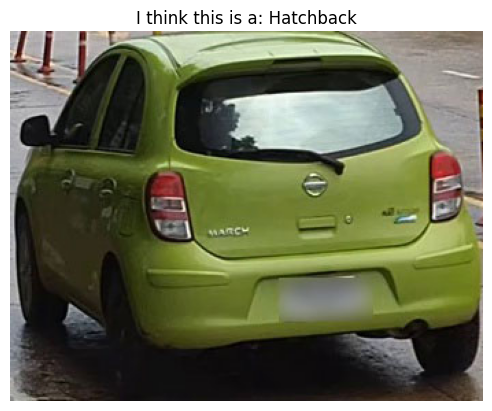

In [19]:
predict_car_type("Test_image3.jpg")

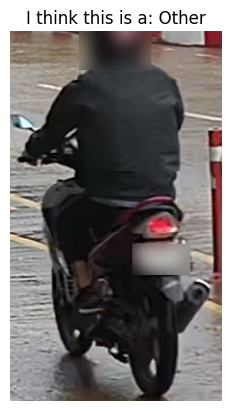

In [20]:
predict_car_type("Test_image4.jpg")